# Google Apps Script Workflow Automation  
## Product Intake → Clean Product Records → Squarespace CSV

**Portfolio artifact purpose:** This notebook documents a practical workflow automation project built with Google Apps Script. It shows the problem, the workflow design, how the script is used, and the complete source code.

This is written as evidence for a personal portfolio, not as a Jupyter-executable analysis notebook. The code is Google Apps Script, so it should be run inside **Google Apps Script**, not inside this notebook. Humanity has invented yet another place where code can exist but not run. Naturally.


## Project Summary

This project automates part of a product-intake workflow for a ceramics website.

The workflow starts with a structured Google Form / Google Sheet intake process, then uses Google Apps Script to clean product data, format product descriptions, calculate shipping-ready values, collect image URLs, and export a Squarespace-compatible CSV file.

### What this project demonstrates

| Skill Area | Evidence in the Project |
|---|---|
| Workflow automation | Uses Google Apps Script to create a repeatable form-to-CSV process |
| Data organization | Standardizes product fields like name, category, price, dimensions, weight, status, and notes |
| Spreadsheet logic | Reads response data from Google Sheets by header names instead of hard-coded row positions |
| Web publishing support | Produces product records formatted for Squarespace import |
| Data cleaning | Cleans numbers, formats dimensions and weights, creates URL slugs, and escapes HTML |
| Documentation | Explains how a non-technical user can collect and prepare product data consistently |


## Workflow Diagram

The intended workflow is simple:

1. Product details are submitted through a Google Form or entered into a response Sheet.
2. Apps Script reads and cleans the spreadsheet rows.
3. Draft-ready product information is generated.
4. A Squarespace-compatible CSV is exported for website upload/import.


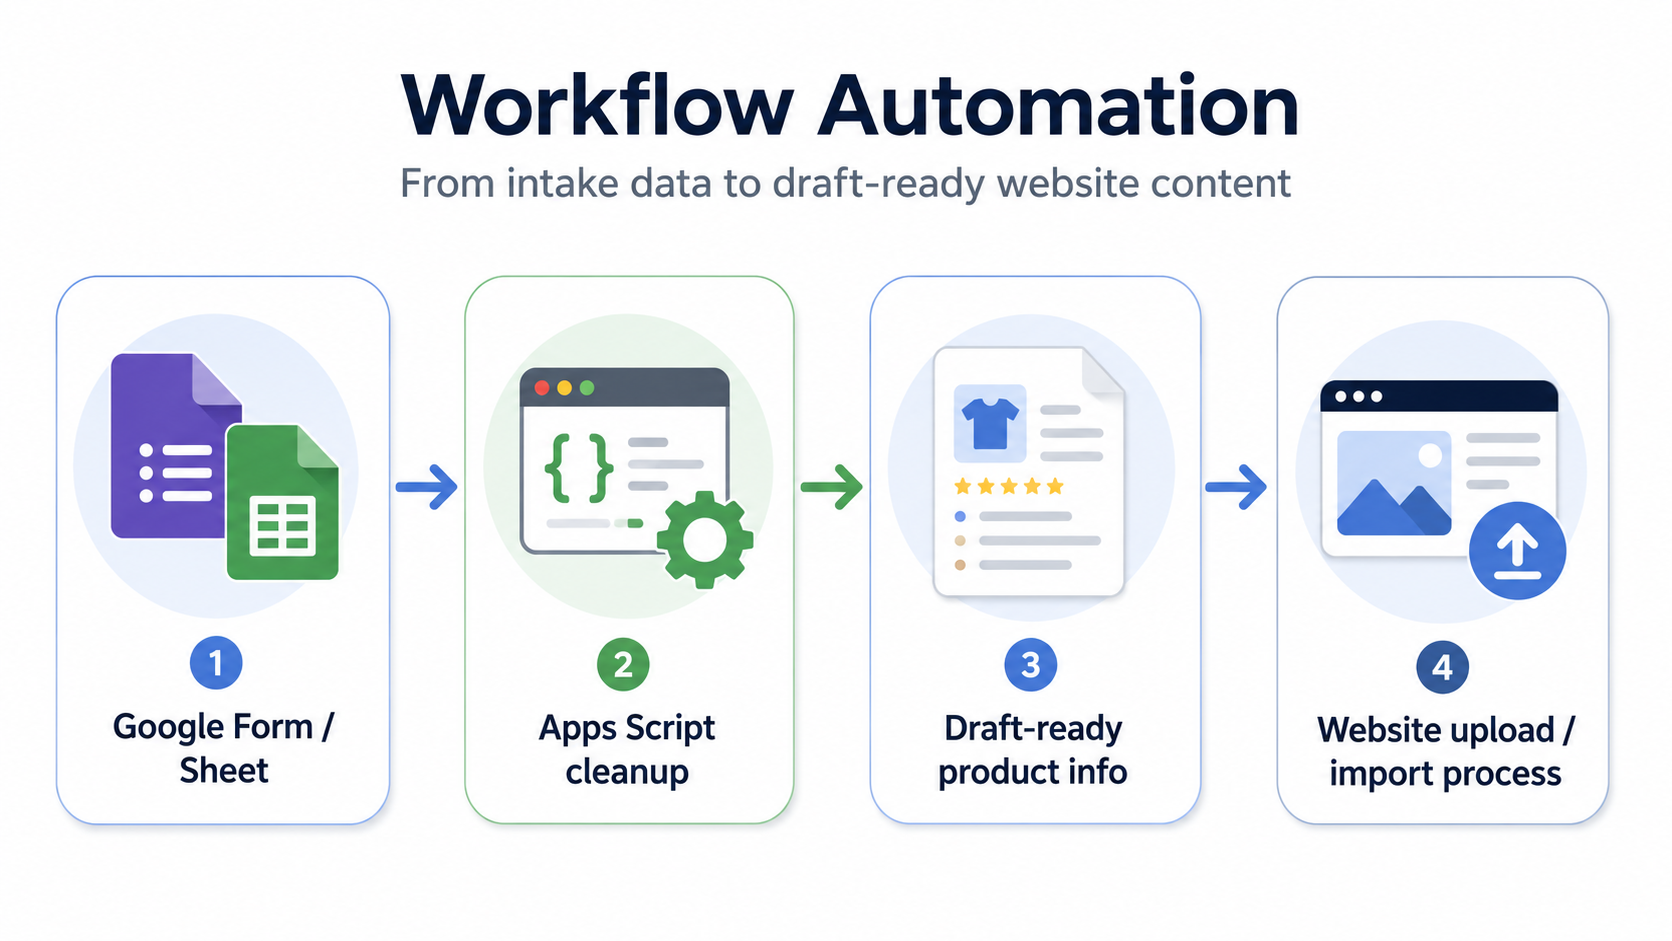

## Problem Being Solved

Manual product entry is repetitive and easy to mess up. For a website with many handmade products, each item needs consistent information:

- product name
- category
- price
- SKU or tracking code
- dimensions
- weight
- care details
- photos
- notes
- website publishing status

Without a structured workflow, product records can become inconsistent, incomplete, or hard to reuse. This script turns that messy intake process into a cleaner pipeline.


## How the Script Works

The Apps Script has two main jobs:

### 1. Create the intake form and response sheet

The `createGlazedAndFiredProductIntakeForm()` function creates a Google Form called **Glazed & Fired Product Intake**, links it to a new response spreadsheet, saves the form and sheet IDs in script properties, and adds organized sections for:

- Product Basics
- Measurements
- Care and Shipping
- Photos
- Squarespace Publishing

### 2. Export a Squarespace-ready CSV

The `exportSquarespaceCsvToDrive()` function reads the response sheet, filters rows marked **Ready for website**, formats each product row for Squarespace, and creates a CSV file in Google Drive.

The export process includes:

- title and slug generation
- HTML product description creation
- price cleaning
- weight/dimension formatting
- photo URL extraction
- CSV escaping so commas, quotes, and line breaks do not break the import


## How to Use This Script

### Step 1: Open Google Apps Script
Go to Google Apps Script and create a new project.

### Step 2: Paste the source code
Paste the complete script from this notebook into the Apps Script editor.

### Step 3: Run the form creation function
Run:

```javascript
createGlazedAndFiredProductIntakeForm()
```

The first time it runs, Google will ask for permissions. Approve them if this is your own script and your own Drive/Form/Sheet environment.

### Step 4: Open the generated links
After the script runs, check the Apps Script log. It will show:

- the Google Form edit link
- the public form/share link
- the response sheet link

### Step 5: Manually add photo upload questions
The script creates a **Photo Uploads** section, but the current version tells the user to manually add four File Upload questions:

- Front photo
- Side photo
- Back photo
- Top photo

That manual step is intentional in this version because file upload behavior in Google Forms can require account/Drive-specific settings. Translation: Google decided to make one tiny part annoying, as is tradition.

### Step 6: Submit test products
Submit one product per form response. Set the product status to:

```text
Ready for website
```

Only rows with that status are exported.

### Step 7: Export the CSV
Run:

```javascript
exportSquarespaceCsvToDrive()
```

The script creates a CSV file in Google Drive named like:

```text
squarespace-products-YYYY-MM-DD-HHMM.csv
```

### Step 8: Review before importing
Open the CSV, review the rows, check images, prices, dimensions, and descriptions, then use it for Squarespace product upload/import.


## Function Map

| Function | Purpose |
|---|---|
| `createGlazedAndFiredProductIntakeForm()` | Creates the Google Form, response spreadsheet, and saves IDs |
| `addProductBasicsSection_()` | Adds product name, category, SKU, price, status, and description fields |
| `addMeasurementsSection_()` | Adds length, height, depth, and weight fields |
| `addCareAndShippingSection_()` | Adds food safe, dishwasher safe, microwave safe, and notes fields |
| `addPhotosSection_()` | Adds photo instructions and photo notes |
| `addSquarespaceSection_()` | Adds pre-publish checklist and Squarespace product URL field |
| `exportSquarespaceCsvToDrive()` | Reads responses and exports a Squarespace-ready CSV |
| `getPublicImageUrls_()` | Extracts Drive file links and converts them into downloadable image URLs |
| `makeDescription_()` | Builds an HTML product description |
| `shippingWeight_()` | Adds a shipping weight buffer |
| `shippingDimension_()` | Adds a packing dimension buffer |
| `slugify_()` | Converts product names into URL-safe slugs |
| `escapeHtml_()` | Prevents HTML-breaking characters in descriptions |
| `toCsvLine_()` | Escapes CSV values correctly |


## Complete Google Apps Script Source Code

This code is intended to be copied into Google Apps Script. It is included here as documentation evidence for the project.

```javascript
function createGlazedAndFiredProductIntakeForm() {
  const form = FormApp.create('Glazed & Fired Product Intake');
  form.setDescription(
    'Submit one form per ceramic piece. Add measurements, price, and 4 photos before entering the product into Squarespace.'
  );
  form.setCollectEmail(false);
  form.setAllowResponseEdits(true);
  form.setConfirmationMessage('Saved. Submit another piece when ready.');

  const sheet = SpreadsheetApp.create('Glazed & Fired Product Intake Responses');
  form.setDestination(FormApp.DestinationType.SPREADSHEET, sheet.getId());

  PropertiesService.getScriptProperties().setProperty('RESPONSE_SHEET_ID', sheet.getId());
  PropertiesService.getScriptProperties().setProperty('FORM_ID', form.getId());

  addProductBasicsSection_(form);
  addMeasurementsSection_(form);
  addCareAndShippingSection_(form);
  addPhotosSection_(form);
  addSquarespaceSection_(form);

  Logger.log('Form edit link: ' + form.getEditUrl());
  Logger.log('Form share link: ' + form.getPublishedUrl());
  Logger.log('Response sheet: ' + sheet.getUrl());
}

function addProductBasicsSection_(form) {
  form.addSectionHeaderItem().setTitle('Product Basics');

  form.addTextItem()
    .setTitle('Piece name')
    .setHelpText('Example: Goldie, Vivian, Blue Floral Frame')
    .setRequired(true);

  form.addListItem()
    .setTitle('Category')
    .setChoiceValues(['Ladies', 'Frames', 'Magnets', 'Bowls', 'Sculpture', 'Other'])
    .setRequired(true);

  form.addTextItem()
    .setTitle('SKU or tracking code')
    .setHelpText('Optional. Example: GF-2026-001')
    .setRequired(false);

  form.addTextItem()
    .setTitle('Price')
    .setHelpText('Numbers only. Example: 95')
    .setRequired(true);

  form.addListItem()
    .setTitle('Status')
    .setChoiceValues([
      'Ready for website',
      'Uploaded to Squarespace',
      'Hold for show',
      'Sold',
      'Needs photos',
      'Needs measurements',
    ])
    .setRequired(true);

  form.addParagraphTextItem()
    .setTitle('Short description')
    .setHelpText('One or two sentences. This can become the Squarespace product description.')
    .setRequired(false);
}

function addMeasurementsSection_(form) {
  form.addPageBreakItem().setTitle('Measurements');

  form.addTextItem()
    .setTitle('Length in inches')
    .setRequired(true);

  form.addTextItem()
    .setTitle('Height in inches')
    .setRequired(true);

  form.addTextItem()
    .setTitle('Depth in inches')
    .setRequired(true);

  form.addTextItem()
    .setTitle('Weight in pounds')
    .setHelpText('Use packed shipping weight if you know it. Otherwise use piece weight and update before publishing.')
    .setRequired(true);
}

function addCareAndShippingSection_(form) {
  form.addPageBreakItem().setTitle('Care and Shipping');

  form.addMultipleChoiceItem()
    .setTitle('Food safe?')
    .setChoiceValues(['Yes', 'No', 'Not sure'])
    .setRequired(true);

  form.addMultipleChoiceItem()
    .setTitle('Dishwasher safe?')
    .setChoiceValues(['Yes', 'No', 'Hand wash recommended', 'Not sure'])
    .setRequired(true);

  form.addMultipleChoiceItem()
    .setTitle('Microwave safe?')
    .setChoiceValues(['Yes', 'No', 'Not sure'])
    .setRequired(true);

  form.addParagraphTextItem()
    .setTitle('Notes')
    .setHelpText('Damage, special packing, show hold, customer hold, glaze notes, etc.')
    .setRequired(false);
}

function addPhotosSection_(form) {
  form.addPageBreakItem().setTitle('Photos');

  form.addSectionHeaderItem()
    .setTitle('Photo Uploads')
    .setHelpText('After this form is created, manually add 4 File upload questions here: front, side, back, top.');

  form.addParagraphTextItem()
    .setTitle('Photo notes')
    .setHelpText('Optional: note anything about the photos, filenames, or missing shots.')
    .setRequired(false);
}

function addSquarespaceSection_(form) {
  form.addPageBreakItem().setTitle('Squarespace Publishing');

  form.addCheckboxItem()
    .setTitle('Pre-publish checklist')
    .setChoiceValues([
      'Photos look good',
      'Price is correct',
      'Quantity should be 1',
      'Measurements entered',
      'Weight entered',
      'Ready to add to Squarespace',
    ])
    .setRequired(false);

  form.addTextItem()
    .setTitle('Squarespace product URL')
    .setHelpText('Fill this later after the product is created.')
    .setRequired(false);
}

function exportSquarespaceCsvToDrive() {
  const sheetId = PropertiesService.getScriptProperties().getProperty('RESPONSE_SHEET_ID');
  if (!sheetId) {
    throw new Error('No response sheet saved yet. Run createGlazedAndFiredProductIntakeForm first.');
  }

  const ss = SpreadsheetApp.openById(sheetId);
  const sheet = ss.getSheets()[0];
  const range = sheet.getDataRange();
  const values = range.getDisplayValues();
  const richTextValues = range.getRichTextValues();

  if (values.length < 2) {
    throw new Error('No form responses found yet. Submit one test item first.');
  }

  const headers = values[0];
  const csvRows = [getSquarespaceHeaders_()];

  for (let r = 1; r < values.length; r++) {
    const row = values[r];
    const title = getByHeader_(row, headers, 'Piece name');
    if (!title) continue;

    const status = getByHeader_(row, headers, 'Status');
    if (status && status !== 'Ready for website') continue;

    const imageUrls = [
      'Front photo',
      'Side photo',
      'Back photo',
      'Top photo',
    ].flatMap(photoHeader => getPublicImageUrls_(richTextValues[r], headers, photoHeader));

    csvRows.push([
      '',
      '',
      'PHYSICAL',
      'shop',
      slugify_(title),
      title,
      makeDescription_(row, headers),
      getByHeader_(row, headers, 'SKU or tracking code'),
      '',
      '',
      '',
      '',
      '',
      '',
      '',
      '',
      cleanNumber_(getByHeader_(row, headers, 'Price')),
      '',
      'No',
      '1',
      '',
      'Glazed & Fired',
      shippingWeight_(getByHeader_(row, headers, 'Weight in pounds')),
      shippingDimension_(getByHeader_(row, headers, 'Length in inches')),
      shippingDimension_(getByHeader_(row, headers, 'Depth in inches')),
      shippingDimension_(getByHeader_(row, headers, 'Height in inches')),
      'No',
      imageUrls.join('\n'),
    ]);
  }

  const csv = csvRows.map(toCsvLine_).join('\r\n');
  const fileName = 'squarespace-products-' + Utilities.formatDate(
    new Date(),
    Session.getScriptTimeZone(),
    'yyyy-MM-dd-HHmm'
  ) + '.csv';

  const file = DriveApp.createFile(fileName, csv, MimeType.CSV);
  Logger.log('Squarespace CSV: ' + file.getUrl());
}

function getPublicImageUrls_(richTextRow, headers, photoHeader) {
  const index = headers.indexOf(photoHeader);
  if (index === -1) return [];

  const richText = richTextRow[index];
  const links = [];

  if (richText.getLinkUrl()) {
    links.push(richText.getLinkUrl());
  }

  richText.getRuns().forEach(run => {
    const url = run.getLinkUrl();
    if (url) links.push(url);
  });

  return [...new Set(links)].map(link => {
    const fileId = extractDriveFileId_(link);
    if (!fileId) return '';

    const file = DriveApp.getFileById(fileId);
    file.setSharing(DriveApp.Access.ANYONE_WITH_LINK, DriveApp.Permission.VIEW);

    return 'https://drive.google.com/uc?export=download&id=' + encodeURIComponent(fileId);
  }).filter(Boolean);
}

function extractDriveFileId_(url) {
  const match = String(url || '').match(/[-\w]{25,}/);
  return match ? match[0] : '';
}

function makeDescription_(row, headers) {
  const name = getByHeader_(row, headers, 'Piece name');
  const notes = getByHeader_(row, headers, 'Notes');

  const width = getByHeader_(row, headers, 'Length in inches');
  const height = getByHeader_(row, headers, 'Height in inches');
  const depth = getByHeader_(row, headers, 'Depth in inches');
  const weightPounds = getByHeader_(row, headers, 'Weight in pounds');
  const weightOz = poundsToOunces_(weightPounds);

  const descriptionParts = [];

  descriptionParts.push(
    '<p>Meet ' + escapeHtml_(name) + ', a one of a kind, handmade clay sculpture. Kiln fired twice, high-fire glaze.</p>'
  );

  if (weightOz) {
    descriptionParts.push('<p>WEIGHT: ' + escapeHtml_(weightOz) + ' oz</p>');
  }

  if (width || height || depth) {
    descriptionParts.push(
      '<p>SIZE: Width ' + escapeHtml_(width) + ' in | Height ' + escapeHtml_(height) + ' in | Depth ' + escapeHtml_(depth) + ' in</p>'
    );
  }

  if (notes) {
    descriptionParts.push('<p>' + escapeHtml_(notes).replace(/\n+/g, '</p><p>') + '</p>');
  }

  descriptionParts.push(
    '<p>*Please note: Any minor imperfections are not considered defects, they are evidence of an original, unique, handcrafted piece of artwork created by an artisan.</p>'
  );

  descriptionParts.push('<p>ALL SALES ARE FINAL</p>');

  return descriptionParts.join('');
}

function poundsToOunces_(pounds) {
  const number = parseFloat(String(pounds || '').replace(/[^\d.]/g, ''));
  if (!number) return '';

  const ounces = number * 16;
  return formatDecimal_(ounces, 1);
}

function getByHeader_(row, headers, headerName) {
  const index = headers.indexOf(headerName);
  return index === -1 ? '' : row[index];
}

function getSquarespaceHeaders_() {
  return [
    'Product ID [Non Editable]',
    'Variant ID [Non Editable]',
    'Product Type [Non Editable]',
    'Product Page',
    'Product URL',
    'Title',
    'Description',
    'SKU',
    'GTIN',
    'MPN',
    'Option Name 1',
    'Option Value 1',
    'Option Name 2',
    'Option Value 2',
    'Option Name 3',
    'Option Value 3',
    'Price',
    'Sale Price',
    'On Sale',
    'Stock',
    'Categories',
    'Tags',
    'Weight',
    'Length',
    'Width',
    'Height',
    'Visible',
    'Hosted Image URLs',
  ];
}

function shippingWeight_(value) {
  const number = parseNumber_(value);
  if (!number) return '';
  return formatSquarespaceWeight_(number * 1.2);
}

function shippingDimension_(value) {
  const number = parseNumber_(value);
  if (!number) return '';
  return formatDecimal_(number + 1, 2);
}

function cleanNumber_(value) {
  const number = parseNumber_(value);
  return number ? formatDecimal_(number, 2) : '';
}

function parseNumber_(value) {
  const match = String(value || '').match(/\d+(\.\d+)?/);
  return match ? parseFloat(match[0]) : 0;
}

function formatSquarespaceWeight_(number) {
  const text = formatDecimal_(number, 2);
  return number < 1 ? text.replace(/^0/, '') : text;
}

function formatDecimal_(number, places) {
  return Number(number.toFixed(places)).toString();
}

function slugify_(text) {
  return String(text || '')
    .toLowerCase()
    .replace(/&/g, ' and ')
    .replace(/[^a-z0-9]+/g, '-')
    .replace(/^-+|-+$/g, '');
}

function escapeHtml_(text) {
  return String(text || '')
    .replace(/&/g, '&amp;')
    .replace(/</g, '&lt;')
    .replace(/>/g, '&gt;')
    .replace(/"/g, '&quot;')
    .replace(/'/g, '&#39;');
}

function toCsvLine_(row) {
  return row.map(value => {
    const text = String(value || '');
    return /[",\r\n]/.test(text) ? '"' + text.replace(/"/g, '""') + '"' : text;
  }).join(',');
}
```


## Portfolio Case Study Blurb

**Google Apps Script Product Intake Automation**

Built a Google Apps Script workflow to organize product-intake spreadsheet data into cleaner, draft-ready records for website listing management. The script creates a structured Google Form and response Sheet, then exports rows marked “Ready for website” into a Squarespace-compatible CSV. The project demonstrates workflow automation, spreadsheet data cleanup, structured documentation, and practical scripting for real-world website operations.


## Limitations and Future Improvements

This version is useful as a workflow automation artifact, but it still has room to improve:

- The photo upload fields are currently added manually after form creation.
- The script prepares a Squarespace CSV, but it does not directly publish products through a Squarespace API.
- Product copy is generated using a fixed template and could be made more flexible.
- More validation could be added for missing prices, invalid dimensions, duplicate SKUs, or missing photos.
- A sample sanitized response sheet and sample output CSV could be added for a stronger GitHub repo.

### Strong next artifact

For a portfolio or GitHub repository, the best supporting files would be:

1. `README.md`
2. `Code.gs`
3. sample sanitized input CSV
4. sample generated Squarespace CSV
5. workflow diagram PNG
6. this notebook
